In [3]:
# import required libraries
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns

In [4]:
# load dataset and prepare features
df = pd.read_csv("insurance.csv")

features = df.drop(columns=["charges"])
target = df["charges"]

# encode region column using one-hot encoding
features = pd.get_dummies(features, columns=["region"], drop_first=True, dtype=int)

# encode categorical columns to numbers
features["sex"] = features["sex"].map({"female": 1, "male": 0})
features["smoker"] = features["smoker"].map({"yes": 1, "no": 0})

In [5]:
# create interaction features
features["age_smoker"] = features["age"] * features["smoker"]
features["bmi_smoker"] = features["bmi"] * features["smoker"]

In [6]:
# split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

Alpha=0.001 --> MSE: 20922599.87
Alpha=0.1 --> MSE: 20921803.70
Alpha=1 --> MSE: 20914832.64
Alpha=2 --> MSE: 20908106.78
Alpha=5 --> MSE: 20890881.00
Alpha=10 --> MSE: 20872844.79
Alpha=20 --> MSE: 20877828.53
Alpha=30 --> MSE: 20937537.13
Alpha=40 --> MSE: 21046489.29
Alpha=50 --> MSE: 21196929.87
Alpha=100 --> MSE: 22423172.69


<Axes: >

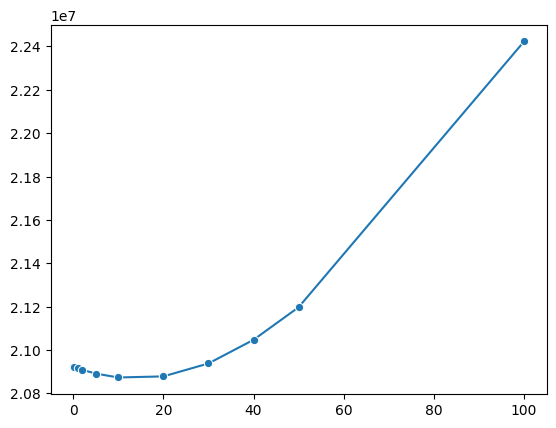

In [7]:
# try different alpha values and check MSE for each
alpha_values = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]
mse_list = []

for a in alpha_values:
    reg = Lasso(alpha=a)
    reg.fit(X_train, y_train)

    preds = reg.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    print(f"Alpha={a} --> MSE: {mse:.2f}")
    mse_list.append(mse)

# plot alpha vs mse
sns.lineplot(x=alpha_values, y=mse_list, marker="o")

In [8]:
# use LassoCV to automatically find the best alpha
alpha_values = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]

best_reg = LassoCV(
    alphas=alpha_values,
    cv=5,
    max_iter=1000,
    random_state=42
)

best_reg.fit(X_train, y_train)

print("Best alpha found:", best_reg.alpha_)

# final predictions
final_preds = best_reg.predict(X_test)
mse = mean_squared_error(y_test, final_preds)
score = r2_score(y_test, final_preds)

print("MSE:", mse)
print("R2 Score:", score)

Best alpha found: 0.001
MSE: 20922599.87103596
R2 Score: 0.8652317499151699
